### Кластеризация

Источник данных: https://www.kaggle.com/datasets/youssefaboelwafa/clustering-penguins-species



Задача: Применить алгоритмы кластеризации (k-means, k-medoids, агломеративный иерархический, DBSCAN) и изучить полученные результаты.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/penguins.csv")
df.sample(5)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
110,38.1,16.5,198.0,3825.0,FEMALE
192,49.0,19.5,210.0,3950.0,MALE
147,36.6,18.4,184.0,3475.0,FEMALE
182,40.9,16.6,187.0,3200.0,FEMALE
326,41.7,14.7,210.0,4700.0,FEMALE


culmen_length -- длина клюва, мм  
culmen_depth -- высота клюва, мм  
flipper_length -- длина плавника, мм  
body_mass -- масса тела, г  
sex -- пол

Заполнение пропусков и стандартизация данных:

In [3]:
df.isna().sum()

culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64

In [4]:
df = df.dropna()

In [5]:
shape = df.shape
print(f"Кол-во пингвинов в выборке: {shape[0]}")
print(f"Кол-во признаков в выборке: {shape[1]}")

Кол-во пингвинов в выборке: 335
Кол-во признаков в выборке: 5


In [6]:
df["sex"] = (df["sex"] == "MALE").astype("int")

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_transformed = scaler.fit_transform(df)
df_transformed = pd.DataFrame(df_transformed, columns=scaler.get_feature_names_out())


Оптимальное число кластеров по Gap-статистике: 3


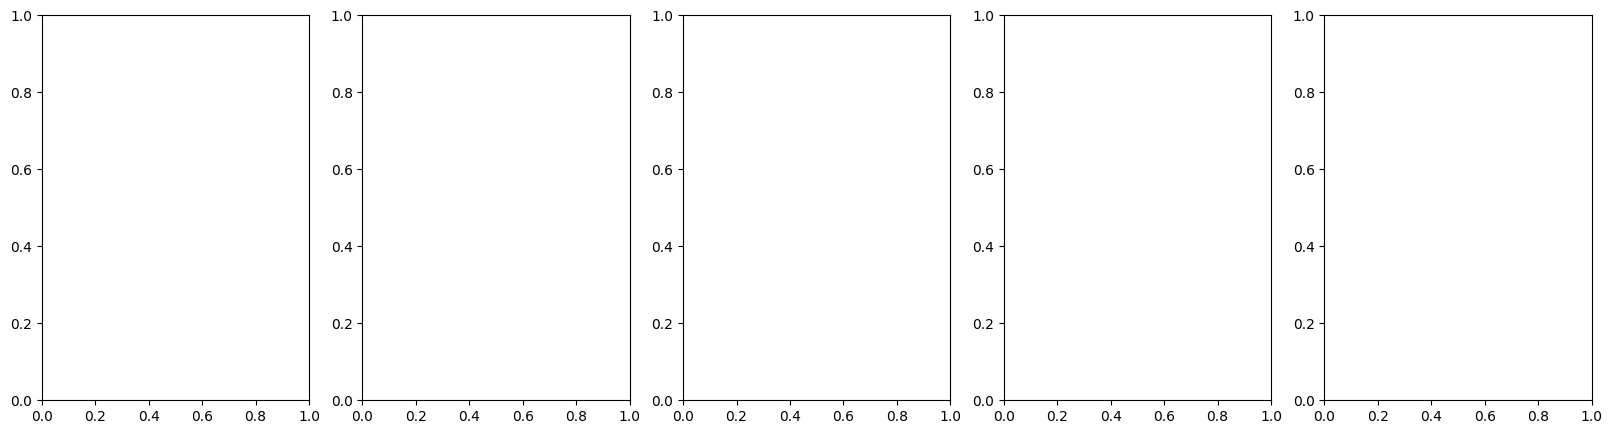

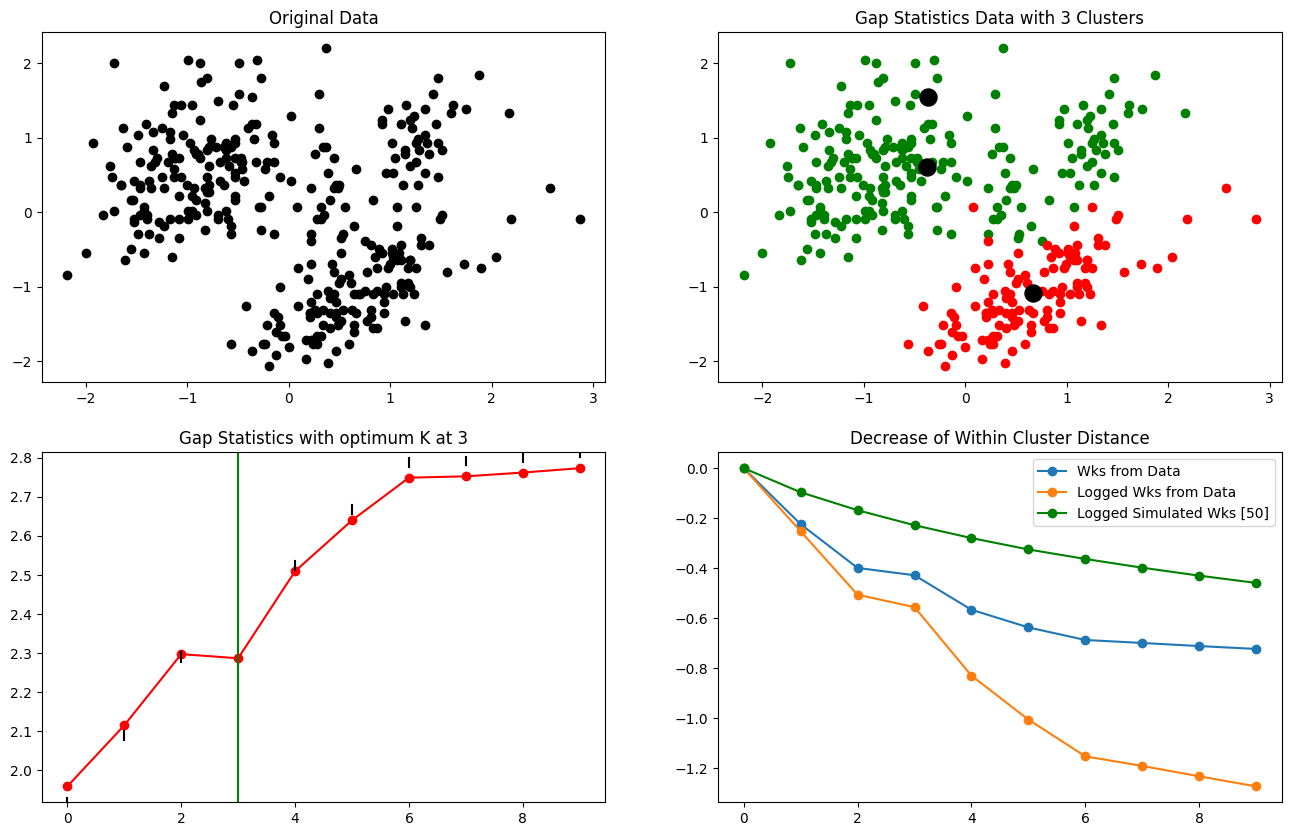

In [ ]:
from gapstatistics.gapstatistics import GapStatistics

fig, axe = plt.subplots(1, 5, figsize=(20, 5))
X = df_transformed.to_numpy()

gs = GapStatistics(return_params=True)
K_max = 10

optimum_k, params = gs.fit_predict(K=K_max, X=X, n_iterations=50)

print(f"Оптимальное число кластеров по Gap-статистике: {optimum_k}")

gs.plot()

Построим 3 кластера:

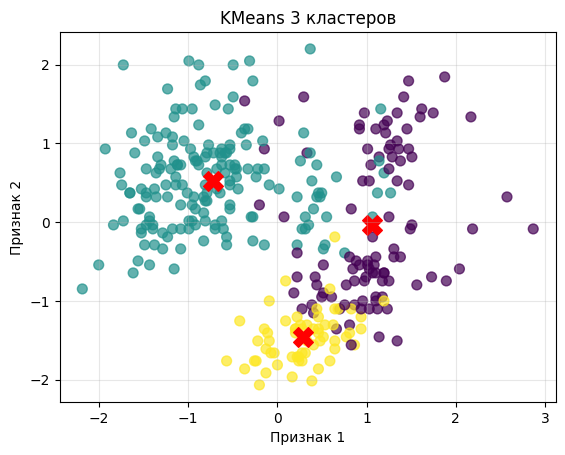

In [ ]:
from sklearn.cluster import KMeans

num_clusters = 3

kmeans = KMeans(n_clusters=num_clusters, n_init="auto")
labels_means = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels_means, s=50, alpha=0.7)

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', s=200, marker='X', label='Центры кластера(ов)')

plt.title(f'KMeans {num_clusters} кластеров')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True, alpha=0.3)

Алгоритм K-means выделил три вида пингвинов на основе имеющихся данных. Один вид (бирюзовые точки) от остальных отделяется хорошо, два других расположены вплотную. Наименьший внутригрупповой разброс имеет вид, обозаченный желтыми точками, а наибольший -- фиолетовыми.

#### DBSCAN

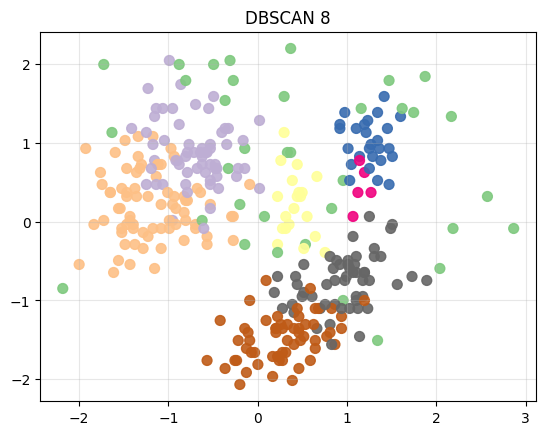

In [ ]:
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels_dbscan, s=50, cmap='Accent', alpha=0.9)
plt.title(f'DBSCAN {len(set(dbscan.labels_))} кластера(ов)')
plt.grid(True, alpha=0.3)
plt.show()

Алгоритм DBSCAN выделил 8 кластеров. На графике видно, что зеленые точки представляют собой не кластер, а объекты-выбросы.